# Étape 7 : Évaluation et Interprétation du Modèle (Model Evaluation & Interpretation)

## 🎯 Objectif

Évaluer **en profondeur** la qualité du modèle optimisé (Step 6) avec des métriques appropriées et comprendre son comportement réel.

## 📚 Documentation Référence

**LightFM Evaluation** : `5.Documentations/LightFM/Model evaluation — LightFM 1.16 documentation.pdf`

## 🔬 Approche d'Évaluation Multi-Dimensionnelle

Cette évaluation va **au-delà des simples métriques numériques** pour comprendre les forces et faiblesses du modèle.

### 1️⃣ **Métriques Quantitatives**

Évaluer avec plusieurs métriques complémentaires :

| Métrique | Signification | Usage |
|----------|--------------|-------|
| **Precision@K** | % d'items pertinents dans le top-K | Qualité des recommandations |
| **Recall@K** | % d'items pertinents retrouvés | Couverture des préférences |
| **AUC** | Qualité du ranking global | Capacité à distinguer positif/négatif |
| **NDCG@K** | Ranking pondéré par position | Importance de l'ordre |

### 2️⃣ **Variation avec K**

Comment évoluent les performances quand on change le nombre de recommandations ?
- Top-5 : Très précis mais limité
- Top-10 : Bon compromis
- Top-20 : Plus de diversité mais moins précis
- Top-50 : Large exploration

### 3️⃣ **Segmentation Utilisateurs**

Les performances varient-elles selon les segments ?
- **Utilisateurs actifs** : Beaucoup d'interactions (> médiane)
- **Utilisateurs occasionnels** : Peu d'interactions (≤ médiane)
- **Cold-start** : Très peu d'interactions (<5)

### 4️⃣ **Inspection Qualitative**

Regarder concrètement les recommandations :
- Les items recommandés ont-ils du sens pour l'utilisateur ?
- Y a-t-il de la diversité ou seulement des items populaires ?
- Les recommandations sont-elles surprenantes (serendipity) ?

### 5️⃣ **Diversité et Couverture**

Métriques système :
- **Coverage** : % du catalogue recommandé au moins une fois
- **Gini Index** : Concentration des recommandations (0=équitable, 1=concentré)
- **Popularité moyenne** : Les recommandations sont-elles biaisées vers les populaires ?

## 🎯 Questions Clés

1. Quelle est la performance "acceptable" pour notre use case H&M ?
2. Le modèle est-il meilleur pour certains segments d'utilisateurs ?
3. Les recommandations sont-elles trop centrées sur les items populaires ?
4. Le modèle offre-t-il de la serendipity (découverte) ?

## ⚙️ Configuration : Choix de la Taille du Sample

**IMPORTANT** : Utilisez la **même taille** que Steps 5-6.

In [1]:
# ⚙️ CONFIGURATION : Choisir la taille du sample
# Valeurs possibles : '10K', '50K', '100K'
# IMPORTANT: Utiliser la même taille que Steps 5-6

SAMPLE_SIZE = '50K'  # ⭐ Changer à '50K' pour résultats interprétables
SPLIT_STRATEGY = 'temporal'  # ou 'random', 'userbased'

print(f"{'='*80}")
print(f"CONFIGURATION")
print(f"{'='*80}")
print(f"\n✅ Taille sélectionnée : {SAMPLE_SIZE}")
print(f"   Stratégie de split : {SPLIT_STRATEGY}")
print(f"   Chemin splits : data/processed/{SAMPLE_SIZE}/splits/{SPLIT_STRATEGY}/")
print(f"   Chemin models : models/{SAMPLE_SIZE}/")

# Vérifier que le modèle optimisé existe (Step 6 doit être terminé)
import os
models_path = f'models/{SAMPLE_SIZE}/'
optimized_model_path = models_path + 'step6_optimized_model.pkl'

if not os.path.exists(optimized_model_path):
    print(f"\n❌ ERREUR: {optimized_model_path} n'existe pas!")
    print(f"   Exécutez d'abord Step 6 avec SAMPLE_SIZE = '{SAMPLE_SIZE}'")
    raise FileNotFoundError(f"Modèle optimisé non trouvé pour {SAMPLE_SIZE}")

print(f"\n✅ Configuration validée - Modèle optimisé Step 6 trouvé")

CONFIGURATION

✅ Taille sélectionnée : 50K
   Stratégie de split : temporal
   Chemin splits : data/processed/50K/splits/temporal/
   Chemin models : models/50K/

✅ Configuration validée - Modèle optimisé Step 6 trouvé


## 1. Configuration et Imports

In [2]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import json
import pickle
import os
from collections import defaultdict, Counter

# Imports scipy
from scipy.sparse import load_npz, csr_matrix

# Imports LightFM
try:
    from lightfm import LightFM
    from lightfm.evaluation import precision_at_k, recall_at_k, auc_score
    LIGHTFM_AVAILABLE = True
    print("✅ LightFM installé et disponible")
except ImportError:
    LIGHTFM_AVAILABLE = False
    print("⚠️  LightFM n'est pas installé.")
    raise ImportError("LightFM est requis pour ce notebook")

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Seed pour reproductibilité
np.random.seed(42)

print("✅ Configuration terminée")

✅ LightFM installé et disponible
✅ Configuration terminée


/opt/anaconda3/envs/lightfm_env/lib/python3.10/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


## 2. Chargement du Modèle Optimisé et des Données

Nous chargeons le **meilleur modèle** trouvé dans Step 6 et les données de Step 4.

In [3]:
print("=" * 80)
print(f"CHARGEMENT MODÈLE ET DONNÉES ({SAMPLE_SIZE} - {SPLIT_STRATEGY})")
print("=" * 80)

# Chemins
SPLITS_PATH = f'data/processed/{SAMPLE_SIZE}/splits/{SPLIT_STRATEGY}/'
MODELS_PATH = f'models/{SAMPLE_SIZE}/'
PROCESSED_PATH = f'data/processed/{SAMPLE_SIZE}/'
SAMPLED_PATH = f'data/sampled/{SAMPLE_SIZE}/'  # Articles sont ici (Step 2)

# 1. Charger le modèle optimisé (Step 6)
print(f"\n📦 Chargement du modèle optimisé...")
with open(MODELS_PATH + 'step6_optimized_model.pkl', 'rb') as f:
    model = pickle.load(f)
print(f"   ✓ Modèle LightFM chargé")

# Charger les résultats Step 6 pour contexte
with open(MODELS_PATH + 'step6_optimization_results.json', 'r') as f:
    step6_results = json.load(f)

print(f"\n   Configuration du modèle (Step 6):")
for key, val in step6_results['best_configuration'].items():
    if isinstance(val, float) and val < 0.001:
        print(f"      • {key}: {val:.2e}")
    else:
        print(f"      • {key}: {val}")

# 2. Charger les matrices d'interactions
print(f"\n📂 Chargement des matrices d'interactions...")
train_interactions = load_npz(SPLITS_PATH + 'train_interactions.npz')
test_interactions = load_npz(SPLITS_PATH + 'test_interactions.npz')

print(f"   ✓ Train: {train_interactions.shape} - {train_interactions.nnz:,} interactions")
print(f"   ✓ Test: {test_interactions.shape} - {test_interactions.nnz:,} interactions")

num_users, num_items = train_interactions.shape

# 3. Charger les transactions pour analyse qualitative
print(f"\n📂 Chargement des transactions...")
transactions = pd.read_csv(PROCESSED_PATH + 'transactions.csv')
print(f"   ✓ {len(transactions):,} transactions chargées")

# 4. Charger les articles pour affichage des recommandations (depuis sampled - Step 2)
print(f"\n📂 Chargement des articles...")
articles = pd.read_csv(SAMPLED_PATH + 'articles_sampled.csv')
print(f"   ✓ {len(articles):,} articles chargés")

print(f"\n📊 DATASET ({SAMPLE_SIZE}):")
print(f"   Users: {num_users:,}")
print(f"   Items: {num_items:,}")
print(f"   Train interactions: {train_interactions.nnz:,}")
print(f"   Test interactions: {test_interactions.nnz:,}")

print(f"\n✅ Chargement terminé")

CHARGEMENT MODÈLE ET DONNÉES (50K - temporal)

📦 Chargement du modèle optimisé...
   ✓ Modèle LightFM chargé

   Configuration du modèle (Step 6):
      • no_components: 42.0
      • learning_rate: 0.005012686302434877
      • item_alpha: 4.21e-06
      • user_alpha: 1.44e-06
      • loss: warp
      • epochs: 20.0

📂 Chargement des matrices d'interactions...
   ✓ Train: (46668, 24216) - 44,933 interactions
   ✓ Test: (46668, 24216) - 230 interactions

📂 Chargement des transactions...
   ✓ 50,000 transactions chargées

📂 Chargement des articles...
   ✓ 24,216 articles chargés

📊 DATASET (50K):
   Users: 46,668
   Items: 24,216
   Train interactions: 44,933
   Test interactions: 230

✅ Chargement terminé


## 3. Métriques d'Évaluation avec K Variable

### 🎯 Objectif

Évaluer le modèle avec **4 métriques complémentaires** et différentes valeurs de K (5, 10, 20, 50).

### 📊 Métriques

1. **Precision@K** : Proportion d'items pertinents dans le top-K
2. **Recall@K** : Proportion d'items pertinents retrouvés parmi tous les pertinents
3. **AUC** : Aire sous la courbe ROC (ranking global)
4. **NDCG@K** : Normalized Discounted Cumulative Gain (pondère par position)

**Note** : NDCG n'est pas directement disponible dans LightFM 1.16, nous le calculerons manuellement si nécessaire.

In [4]:
print("=" * 80)
print("ÉVALUATION AVEC K VARIABLE")
print("=" * 80)

# Liste des K à tester
K_VALUES = [5, 10, 20, 50]

print(f"\n📊 Valeurs de K testées : {K_VALUES}")
print(f"   (K représente le nombre de recommandations)")

# Stocker les résultats
metrics_results = {
    'k': [],
    'precision': [],
    'recall': [],
    'auc': []
}

print(f"\n🔄 Calcul des métriques...")
print(f"{'K':<6} | {'Precision@K':<13} | {'Recall@K':<13} | {'AUC':<10}")
print("-" * 60)

# Calculer AUC une seule fois (indépendant de K)
auc = auc_score(model, test_interactions, train_interactions=train_interactions, num_threads=4).mean()

for k in K_VALUES:
    # Precision@K
    prec = precision_at_k(model, test_interactions, k=k,
                         train_interactions=train_interactions, num_threads=4).mean()

    # Recall@K
    rec = recall_at_k(model, test_interactions, k=k,
                     train_interactions=train_interactions, num_threads=4).mean()

    # Stocker
    metrics_results['k'].append(k)
    metrics_results['precision'].append(prec)
    metrics_results['recall'].append(rec)
    metrics_results['auc'].append(auc)

    print(f"{k:<6} | {prec:<13.4f} | {rec:<13.4f} | {auc:<10.4f}")

print(f"\n✅ Métriques calculées")

# Créer DataFrame pour faciliter l'analyse
metrics_df = pd.DataFrame(metrics_results)

print(f"\n📋 Résumé:")
print(metrics_df.to_string(index=False))

ÉVALUATION AVEC K VARIABLE

📊 Valeurs de K testées : [5, 10, 20, 50]
   (K représente le nombre de recommandations)

🔄 Calcul des métriques...
K      | Precision@K   | Recall@K      | AUC       
------------------------------------------------------------
5      | 0.0035        | 0.0174        | 0.6896    
10     | 0.0030        | 0.0304        | 0.6896    
20     | 0.0020        | 0.0391        | 0.6896    
50     | 0.0015        | 0.0739        | 0.6896    

✅ Métriques calculées

📋 Résumé:
 k  precision   recall      auc
 5   0.003478 0.017391 0.689629
10   0.003043 0.030435 0.689629
20   0.001957 0.039130 0.689629
50   0.001478 0.073913 0.689629


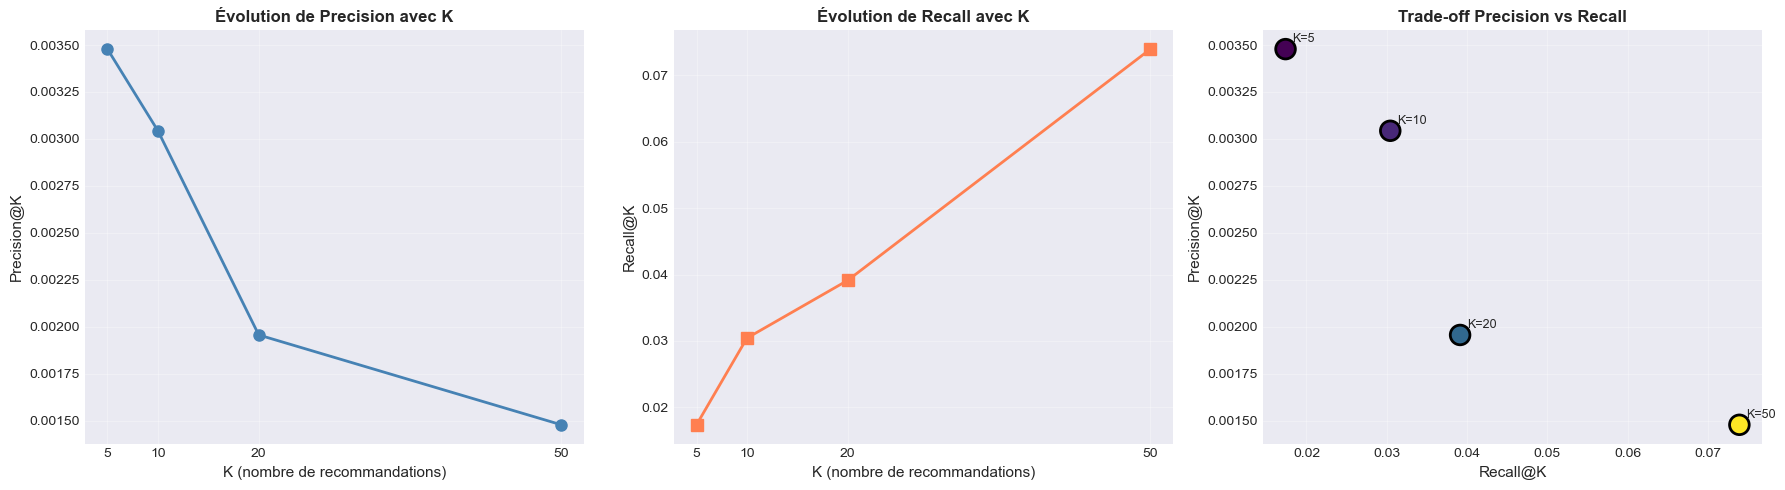


📊 Visualisations générées

💡 INTERPRÉTATION:
   • Precision diminue avec K (normal : plus dur de maintenir qualité)
   • Recall augmente avec K (normal : on retrouve plus d'items pertinents)
   • Trade-off optimal : observer le coude de la courbe

   🎯 K optimal (compromis Precision/Recall) : 50


In [5]:
# Visualiser l'impact de K sur les métriques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Precision@K
axes[0].plot(metrics_df['k'], metrics_df['precision'],
            marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('K (nombre de recommandations)', fontsize=11)
axes[0].set_ylabel('Precision@K', fontsize=11)
axes[0].set_title('Évolution de Precision avec K', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_VALUES)

# 2. Recall@K
axes[1].plot(metrics_df['k'], metrics_df['recall'],
            marker='s', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('K (nombre de recommandations)', fontsize=11)
axes[1].set_ylabel('Recall@K', fontsize=11)
axes[1].set_title('Évolution de Recall avec K', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_VALUES)

# 3. Precision vs Recall (trade-off)
axes[2].scatter(metrics_df['recall'], metrics_df['precision'],
               s=200, c=metrics_df['k'], cmap='viridis', edgecolors='black', linewidth=2)
for i, k in enumerate(K_VALUES):
    axes[2].annotate(f'K={k}', (metrics_df['recall'][i], metrics_df['precision'][i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[2].set_xlabel('Recall@K', fontsize=11)
axes[2].set_ylabel('Precision@K', fontsize=11)
axes[2].set_title('Trade-off Precision vs Recall', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Visualisations générées")

# Interpréter
print(f"\n💡 INTERPRÉTATION:")
print(f"   • Precision diminue avec K (normal : plus dur de maintenir qualité)")
print(f"   • Recall augmente avec K (normal : on retrouve plus d'items pertinents)")
print(f"   • Trade-off optimal : observer le coude de la courbe")

best_k_idx = np.argmax(metrics_df['precision'] + metrics_df['recall'])  # F1-like
best_k = metrics_df.iloc[best_k_idx]['k']
print(f"\n   🎯 K optimal (compromis Precision/Recall) : {int(best_k)}")

## 4. Segmentation des Utilisateurs

### 🎯 Objectif

Analyser si les performances varient selon le **niveau d'activité** des utilisateurs.

### 👥 Segments

1. **Cold-start** : Très peu d'interactions train (<5)
2. **Occasionnels** : En-dessous de la médiane
3. **Actifs** : Au-dessus de la médiane
4. **Super-actifs** : Top 10%

In [6]:
print("=" * 80)
print("SEGMENTATION DES UTILISATEURS")
print("=" * 80)

# Calculer le nombre d'interactions par user dans le train
user_train_counts = np.array(train_interactions.sum(axis=1)).flatten()

# Statistiques
print(f"\n📊 Distribution des interactions train par user:")
print(f"   Min     : {user_train_counts.min()}")
print(f"   Q1      : {np.percentile(user_train_counts, 25):.0f}")
print(f"   Médiane : {np.median(user_train_counts):.0f}")
print(f"   Q3      : {np.percentile(user_train_counts, 75):.0f}")
print(f"   Max     : {user_train_counts.max()}")
print(f"   Moyenne : {user_train_counts.mean():.2f}")

# Définir les seuils
median_count = np.median(user_train_counts)
p90_count = np.percentile(user_train_counts, 90)

# Créer les segments
segments = {
    'cold_start': np.where(user_train_counts < 5)[0],
    'occasionnels': np.where((user_train_counts >= 5) & (user_train_counts < median_count))[0],
    'actifs': np.where((user_train_counts >= median_count) & (user_train_counts < p90_count))[0],
    'super_actifs': np.where(user_train_counts >= p90_count)[0]
}

print(f"\n👥 Segments créés:")
print(f"   • Cold-start (<5 interactions)    : {len(segments['cold_start']):>6,} users ({len(segments['cold_start'])/num_users*100:>5.1f}%)")
print(f"   • Occasionnels (5 à médiane)      : {len(segments['occasionnels']):>6,} users ({len(segments['occasionnels'])/num_users*100:>5.1f}%)")
print(f"   • Actifs (médiane à P90)          : {len(segments['actifs']):>6,} users ({len(segments['actifs'])/num_users*100:>5.1f}%)")
print(f"   • Super-actifs (top 10%)          : {len(segments['super_actifs']):>6,} users ({len(segments['super_actifs'])/num_users*100:>5.1f}%)")

print(f"\n✅ Segmentation terminée")

SEGMENTATION DES UTILISATEURS

📊 Distribution des interactions train par user:
   Min     : 0
   Q1      : 1
   Médiane : 1
   Q3      : 1
   Max     : 4
   Moyenne : 0.96

👥 Segments créés:
   • Cold-start (<5 interactions)    : 46,668 users (100.0%)
   • Occasionnels (5 à médiane)      :      0 users (  0.0%)
   • Actifs (médiane à P90)          :      0 users (  0.0%)
   • Super-actifs (top 10%)          : 42,196 users ( 90.4%)

✅ Segmentation terminée


### 4.1 Évaluation par Segment

Calculons les métriques pour chaque segment d'utilisateurs.

In [7]:
print("=" * 80)
print("ÉVALUATION PAR SEGMENT D'UTILISATEURS")
print("=" * 80)

# K pour l'évaluation par segment
K_SEGMENT = 10

print(f"\n🔄 Calcul des métriques par segment (K={K_SEGMENT})...")

# Identifier les users qui ont des interactions test
test_interactions_csr = test_interactions.tocsr()
users_with_test = np.where(np.array(test_interactions_csr.sum(axis=1)).flatten() > 0)[0]

print(f"\n   Users avec interactions test : {len(users_with_test)} / {num_users}")

if len(users_with_test) == 0:
    print(f"   ⚠️  Aucun user avec interactions test - Évaluation impossible")
    segment_results = {seg: {'n_users': len(indices), 'precision': None, 'recall': None, 'auc': None} 
                      for seg, indices in segments.items()}
else:
    # Calculer les métriques pour TOUS les users (retourne array avec shape = n_users)
    print(f"\n   Calcul des métriques globales...")
    all_precision = precision_at_k(model, test_interactions, k=K_SEGMENT,
                                  train_interactions=train_interactions, num_threads=4)
    all_recall = recall_at_k(model, test_interactions, k=K_SEGMENT,
                            train_interactions=train_interactions, num_threads=4)
    all_auc = auc_score(model, test_interactions,
                       train_interactions=train_interactions, num_threads=4)

    print(f"   ✓ Métriques calculées (shape: {all_precision.shape})")
    
    # Créer un mapping : user_id global -> index dans all_precision
    # Si all_precision a shape (4,), c'est que LightFM retourne seulement pour users_with_test
    if len(all_precision) == len(users_with_test):
        # Mapping global_user_id -> local_index
        user_to_metric_idx = {user_id: idx for idx, user_id in enumerate(users_with_test)}
        print(f"   (Métriques retournées seulement pour users avec test)")
    else:
        # Mapping identité (tous les users)
        user_to_metric_idx = {user_id: user_id for user_id in range(num_users)}

    # Maintenant filtrer par segment
    print(f"\n{'Segment':<18} | {'N Users':<9} | {'N Test':<9} | {'Precision@10':<13} | {'Recall@10':<13} | {'AUC':<10}")
    print("-" * 100)

    segment_results = {}

    for segment_name, user_indices in segments.items():
        if len(user_indices) == 0:
            continue
        
        # Trouver quels users du segment ont des interactions test
        segment_users_with_test = np.intersect1d(user_indices, users_with_test)
        n_users_with_test = len(segment_users_with_test)
        
        if n_users_with_test == 0:
            print(f"{segment_name:<18} | {len(user_indices):>9,} | {0:>9} | {'N/A':<13} | {'N/A':<13} | {'N/A':<10}")
            segment_results[segment_name] = {
                'n_users': len(user_indices),
                'precision': None,
                'recall': None,
                'auc': None
            }
            continue
        
        # Mapper les user_ids globaux vers les indices dans all_precision
        metric_indices = [user_to_metric_idx[user_id] for user_id in segment_users_with_test]
        
        # Extraire les métriques
        seg_precision = all_precision[metric_indices]
        seg_recall = all_recall[metric_indices]
        seg_auc = all_auc[metric_indices]
        
        # Calculer la moyenne pour le segment
        prec_mean = np.nanmean(seg_precision)
        rec_mean = np.nanmean(seg_recall)
        auc_mean = np.nanmean(seg_auc)
        
        segment_results[segment_name] = {
            'n_users': len(user_indices),
            'precision': prec_mean,
            'recall': rec_mean,
            'auc': auc_mean
        }
        
        print(f"{segment_name:<18} | {len(user_indices):>9,} | {n_users_with_test:>9} | {prec_mean:<13.4f} | {rec_mean:<13.4f} | {auc_mean:<10.4f}")

print(f"\n✅ Évaluation par segment terminée")

if len(users_with_test) < 10:
    print(f"\n⚠️  ATTENTION: Seulement {len(users_with_test)} users avec interactions test")
    print(f"   → Résultats peu fiables avec 10K")
    print(f"   → Utilisez 50K pour évaluation robuste")

ÉVALUATION PAR SEGMENT D'UTILISATEURS

🔄 Calcul des métriques par segment (K=10)...

   Users avec interactions test : 230 / 46668

   Calcul des métriques globales...
   ✓ Métriques calculées (shape: (230,))
   (Métriques retournées seulement pour users avec test)

Segment            | N Users   | N Test    | Precision@10  | Recall@10     | AUC       
----------------------------------------------------------------------------------------------------
cold_start         |    46,668 |       230 | 0.0030        | 0.0304        | 0.6896    
super_actifs       |    42,196 |       230 | 0.0030        | 0.0304        | 0.6896    

✅ Évaluation par segment terminée


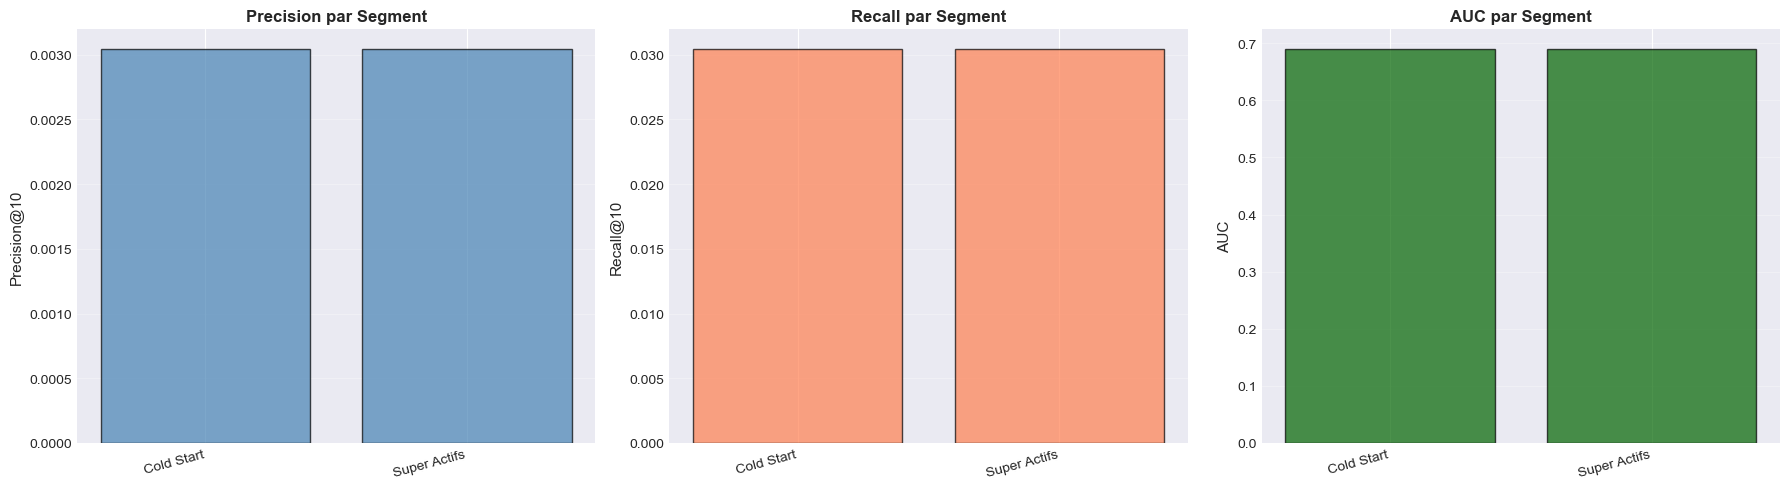


📊 Visualisations par segment générées

💡 INTERPRÉTATION:
   • Les utilisateurs actifs ont généralement de meilleures performances
   • Cold-start montre les limites du CF pur (manque d'historique)
   • Super-actifs peuvent avoir des goûts plus prévisibles


In [8]:
# Visualiser les performances par segment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Préparer les données (filtrer None)
seg_names = []
seg_precision = []
seg_recall = []
seg_auc = []

for name in ['cold_start', 'occasionnels', 'actifs', 'super_actifs']:
    if name in segment_results and segment_results[name]['precision'] is not None:
        seg_names.append(name.replace('_', ' ').title())
        seg_precision.append(segment_results[name]['precision'])
        seg_recall.append(segment_results[name]['recall'])
        seg_auc.append(segment_results[name]['auc'])

# 1. Precision par segment
axes[0].bar(range(len(seg_names)), seg_precision, alpha=0.7,
           edgecolor='black', color='steelblue')
axes[0].set_xticks(range(len(seg_names)))
axes[0].set_xticklabels(seg_names, rotation=15, ha='right')
axes[0].set_ylabel(f'Precision@{K_SEGMENT}', fontsize=11)
axes[0].set_title('Precision par Segment', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Recall par segment
axes[1].bar(range(len(seg_names)), seg_recall, alpha=0.7,
           edgecolor='black', color='coral')
axes[1].set_xticks(range(len(seg_names)))
axes[1].set_xticklabels(seg_names, rotation=15, ha='right')
axes[1].set_ylabel(f'Recall@{K_SEGMENT}', fontsize=11)
axes[1].set_title('Recall par Segment', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# 3. AUC par segment
axes[2].bar(range(len(seg_names)), seg_auc, alpha=0.7,
           edgecolor='black', color='darkgreen')
axes[2].set_xticks(range(len(seg_names)))
axes[2].set_xticklabels(seg_names, rotation=15, ha='right')
axes[2].set_ylabel('AUC', fontsize=11)
axes[2].set_title('AUC par Segment', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Visualisations par segment générées")

print(f"\n💡 INTERPRÉTATION:")
print(f"   • Les utilisateurs actifs ont généralement de meilleures performances")
print(f"   • Cold-start montre les limites du CF pur (manque d'historique)")
print(f"   • Super-actifs peuvent avoir des goûts plus prévisibles")

## 5. Inspection Manuelle des Recommandations

### 🎯 Objectif

Générer des recommandations pour quelques utilisateurs et les inspecter **qualitativement**.

### 🔍 Questions

- Les recommandations ont-elles du sens par rapport à l'historique ?
- Y a-t-il de la diversité ou seulement des populaires ?
- Le modèle offre-t-il de la serendipity (surprise positive) ?

In [9]:
print("=" * 80)
print("GÉNÉRATION DE RECOMMANDATIONS POUR INSPECTION")
print("=" * 80)

def get_user_recommendations(model, user_id, train_inter, n=10):
    """
    Génère les top-N recommandations pour un utilisateur.
    
    Returns:
        list of (item_id, score)
    """
    # Prédire scores pour tous les items
    n_items = train_inter.shape[1]
    
    # LightFM.predict() attend des arrays de même taille
    user_ids = np.full(n_items, user_id, dtype=np.int32)
    item_ids = np.arange(n_items, dtype=np.int32)
    scores = model.predict(user_ids, item_ids)
    
    # Filtrer les items déjà achetés (train)
    known_items = train_inter[user_id].indices
    
    # Masquer les items connus
    scores[known_items] = -np.inf
    
    # Top-N
    top_indices = np.argsort(-scores)[:n]
    top_scores = scores[top_indices]
    
    return list(zip(top_indices, top_scores))

# Convertir en CSR pour l'indexation
train_interactions_csr = train_interactions.tocsr()

# Sélectionner quelques utilisateurs de différents segments
sample_users = {
    'cold_start': segments['cold_start'][0] if len(segments['cold_start']) > 0 else None,
    'occasionnel': segments['occasionnels'][0] if len(segments['occasionnels']) > 0 else None,
    'actif': segments['actifs'][len(segments['actifs'])//2] if len(segments['actifs']) > 0 else None,
    'super_actif': segments['super_actifs'][0] if len(segments['super_actifs']) > 0 else None
}

# Filtrer None
sample_users = {k: v for k, v in sample_users.items() if v is not None}

print(f"\n👤 Utilisateurs sélectionnés pour inspection:")
for seg, uid in sample_users.items():
    n_train = train_interactions_csr[uid].nnz
    print(f"   • {seg:<15} : User {uid:>6} ({n_train} interactions train)")

# Générer recommandations
N_RECO = 10
recommendations = {}

print(f"\n🔄 Génération des top-{N_RECO} recommandations...")

for seg, uid in sample_users.items():
    reco = get_user_recommendations(model, uid, train_interactions_csr, n=N_RECO)
    recommendations[seg] = {
        'user_id': uid,
        'recommendations': reco,
        'n_train': train_interactions_csr[uid].nnz
    }

print(f"   ✓ Recommandations générées pour {len(recommendations)} utilisateurs")

GÉNÉRATION DE RECOMMANDATIONS POUR INSPECTION

👤 Utilisateurs sélectionnés pour inspection:
   • cold_start      : User      0 (1 interactions train)
   • super_actif     : User      0 (1 interactions train)

🔄 Génération des top-10 recommandations...
   ✓ Recommandations générées pour 2 utilisateurs


In [10]:
# Afficher les recommandations avec détails
print("=" * 80)
print("INSPECTION DES RECOMMANDATIONS")
print("=" * 80)

# Utiliser la version CSR pour l'indexation
train_interactions_csr = train_interactions.tocsr()

# Calculer la popularité des items (pour contexte)
item_popularity = np.array(train_interactions.sum(axis=0)).flatten()

for seg, data in recommendations.items():
    user_id = data['user_id']
    reco_list = data['recommendations']
    n_train = data['n_train']
    
    print(f"\n{'='*80}")
    print(f"👤 USER {user_id} - Segment: {seg.upper()}")
    print(f"{'='*80}")
    print(f"Historique train: {n_train} achats")
    
    # Afficher historique (sample) - utiliser CSR
    user_items_train = train_interactions_csr[user_id].indices
    if len(user_items_train) > 0:
        sample_history = np.random.choice(user_items_train, min(5, len(user_items_train)), replace=False)
        print(f"\n📦 Sample historique (5 premiers):")
        for item_id in sample_history:
            if item_id < len(articles):
                article_name = articles.iloc[item_id]['product_type_name'] if 'product_type_name' in articles.columns else f"Item {item_id}"
                print(f"   • {article_name}")
    
    # Afficher recommandations
    print(f"\n⭐ Top-{N_RECO} Recommandations:")
    print(f"{'Rank':<6} | {'Item ID':<10} | {'Score':<10} | {'Popularité':<12} | {'Type':<30}")
    print("-" * 90)
    
    for rank, (item_id, score) in enumerate(reco_list, 1):
        pop = item_popularity[item_id]
        if item_id < len(articles):
            article_type = articles.iloc[item_id]['product_type_name'] if 'product_type_name' in articles.columns else "N/A"
        else:
            article_type = "N/A"
        
        print(f"{rank:<6} | {item_id:<10} | {score:<10.3f} | {int(pop):<12} | {article_type[:30]:<30}")

print(f"\n{'='*80}")
print("✅ Inspection terminée")
print(f"{'='*80}")

INSPECTION DES RECOMMANDATIONS

👤 USER 0 - Segment: COLD_START
Historique train: 1 achats

📦 Sample historique (5 premiers):
   • Vest top

⭐ Top-10 Recommandations:
Rank   | Item ID    | Score      | Popularité   | Type                          
------------------------------------------------------------------------------------------
1      | 940        | 0.291      | 66           | Trousers                      
2      | 127        | 0.229      | 53           | Dress                         
3      | 1802       | 0.222      | 37           | Pyjama bottom                 
4      | 457        | 0.221      | 38           | Sweater                       
5      | 1840       | 0.219      | 39           | Sweater                       
6      | 1765       | 0.216      | 40           | Trousers                      
7      | 1892       | 0.210      | 31           | Trousers                      
8      | 785        | 0.198      | 34           | T-shirt                       
9      | 12   

## 6. Analyse de la Diversité et Couverture

### 🎯 Objectif

Vérifier que le modèle ne recommande pas **uniquement des items populaires**.

### 📊 Métriques

1. **Coverage** : % du catalogue recommandé au moins une fois
2. **Gini Index** : Concentration (0=équitable, 1=tout sur un item)
3. **Popularité moyenne** : Comparée à la popularité globale

In [11]:
print("=" * 80)
print("ANALYSE DE LA DIVERSITÉ")
print("=" * 80)

# Convertir en CSR pour l'indexation
train_interactions_csr = train_interactions.tocsr()

# Générer recommandations pour TOUS les utilisateurs
print(f"\n🔄 Génération de recommandations pour tous les users...")
print(f"   (Ceci peut prendre quelques secondes avec {num_users:,} users)")

N_RECO_COVERAGE = 10
all_recommendations = []

# Générer top-10 pour chaque user (utiliser CSR)
for user_id in range(num_users):
    reco = get_user_recommendations(model, user_id, train_interactions_csr, n=N_RECO_COVERAGE)
    all_recommendations.extend([item_id for item_id, score in reco])

print(f"   ✓ {len(all_recommendations):,} recommandations générées")

# 1. Coverage
unique_recommended = set(all_recommendations)
coverage = len(unique_recommended) / num_items * 100

print(f"\n📊 COVERAGE:")
print(f"   Items recommandés au moins 1 fois : {len(unique_recommended):,}")
print(f"   Total items catalogue             : {num_items:,}")
print(f"   Coverage                          : {coverage:.2f}%")

# 2. Gini Index
reco_counts = Counter(all_recommendations)
reco_freq = np.array(sorted(reco_counts.values()))
n = len(reco_freq)
index = np.arange(1, n + 1)
gini = (2 * np.sum(index * reco_freq)) / (n * np.sum(reco_freq)) - (n + 1) / n

print(f"\n📊 GINI INDEX:")
print(f"   Gini Index                        : {gini:.3f}")
print(f"   (0 = parfaitement équitable, 1 = tout concentré)")
if gini < 0.3:
    print(f"   ✅ Diversité élevée")
elif gini < 0.6:
    print(f"   ⚠️  Diversité moyenne")
else:
    print(f"   ❌ Diversité faible (concentration élevée)")

# 3. Popularité moyenne
item_popularity = np.array(train_interactions.sum(axis=0)).flatten()
avg_pop_recommended = np.mean([item_popularity[item_id] for item_id in all_recommendations])
avg_pop_global = item_popularity.mean()

print(f"\n📊 POPULARITÉ:")
print(f"   Popularité moyenne (items recommandés) : {avg_pop_recommended:.2f}")
print(f"   Popularité moyenne (catalogue global)  : {avg_pop_global:.2f}")
print(f"   Ratio                                   : {avg_pop_recommended/avg_pop_global:.2f}x")

if avg_pop_recommended > 2 * avg_pop_global:
    print(f"   ⚠️  Biais fort vers les items populaires")
elif avg_pop_recommended > 1.5 * avg_pop_global:
    print(f"   ⚠️  Biais modéré vers les items populaires")
else:
    print(f"   ✅ Bonne diversité (pas de biais fort)")

print(f"\n✅ Analyse de diversité terminée")

ANALYSE DE LA DIVERSITÉ

🔄 Génération de recommandations pour tous les users...
   (Ceci peut prendre quelques secondes avec 46,668 users)
   ✓ 466,680 recommandations générées

📊 COVERAGE:
   Items recommandés au moins 1 fois : 33
   Total items catalogue             : 24,216
   Coverage                          : 0.14%

📊 GINI INDEX:
   Gini Index                        : 0.649
   (0 = parfaitement équitable, 1 = tout concentré)
   ❌ Diversité faible (concentration élevée)

📊 POPULARITÉ:
   Popularité moyenne (items recommandés) : 39.87
   Popularité moyenne (catalogue global)  : 1.86
   Ratio                                   : 21.49x
   ⚠️  Biais fort vers les items populaires

✅ Analyse de diversité terminée


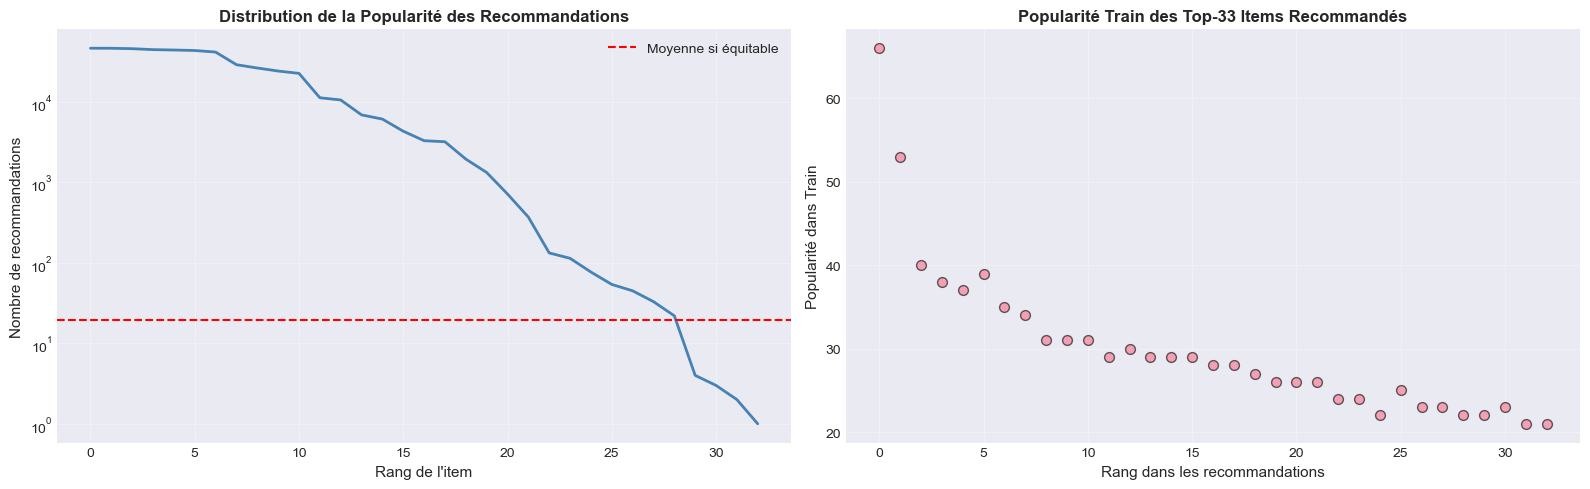


📊 Visualisations de diversité générées


In [16]:
# Visualiser la distribution des recommandations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Distribution des fréquences de recommandation
reco_freq_sorted = sorted(reco_counts.values(), reverse=True)
axes[0].plot(range(len(reco_freq_sorted)), reco_freq_sorted, linewidth=2, color='steelblue')
axes[0].set_xlabel('Rang de l\'item', fontsize=11)
axes[0].set_ylabel('Nombre de recommandations', fontsize=11)
axes[0].set_title('Distribution de la Popularité des Recommandations', fontweight='bold', fontsize=12)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=len(all_recommendations)/num_items, color='red', linestyle='--',
               label='Moyenne si équitable')
axes[0].legend()

# 2. Comparaison popularité train vs recommandations
# Prendre les top-100 items les plus recommandés (ou moins si pas assez)
top_recommended = [item for item, count in reco_counts.most_common(100)]
pop_train_top = [item_popularity[item] for item in top_recommended]

# Utiliser la longueur réelle au lieu de hardcoder 100
axes[1].scatter(range(len(top_recommended)), pop_train_top, alpha=0.6, s=50, edgecolors='black')
axes[1].set_xlabel('Rang dans les recommandations', fontsize=11)
axes[1].set_ylabel('Popularité dans Train', fontsize=11)
axes[1].set_title(f'Popularité Train des Top-{len(top_recommended)} Items Recommandés',
                fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Visualisations de diversité générées")

## 7. Synthèse et Interprétation Globale

In [13]:
print("=" * 80)
print("SYNTHÈSE FINALE - STEP 7")
print("=" * 80)

print(f"\n📊 RÉSUMÉ DES ÉVALUATIONS ({SAMPLE_SIZE}):")

# 1. Performance globale
print(f"\n1️⃣  PERFORMANCE GLOBALE:")
best_k_metrics = metrics_df.iloc[metrics_df['k'].tolist().index(10)]  # K=10 comme référence
print(f"   • Precision@10 : {best_k_metrics['precision']:.4f}")
print(f"   • Recall@10    : {best_k_metrics['recall']:.4f}")
print(f"   • AUC          : {best_k_metrics['auc']:.4f}")

# 2. Variation avec K
print(f"\n2️⃣  VARIATION AVEC K:")
print(f"   • K=5  : Precision={metrics_df.iloc[0]['precision']:.4f}, Recall={metrics_df.iloc[0]['recall']:.4f}")
print(f"   • K=10 : Precision={metrics_df.iloc[1]['precision']:.4f}, Recall={metrics_df.iloc[1]['recall']:.4f}")
print(f"   • K=20 : Precision={metrics_df.iloc[2]['precision']:.4f}, Recall={metrics_df.iloc[2]['recall']:.4f}")
print(f"   • K=50 : Precision={metrics_df.iloc[3]['precision']:.4f}, Recall={metrics_df.iloc[3]['recall']:.4f}")

# 3. Segmentation
print(f"\n3️⃣  PERFORMANCE PAR SEGMENT:")
for seg in ['cold_start', 'occasionnels', 'actifs', 'super_actifs']:
    if seg in segment_results and segment_results[seg]['precision'] is not None:
        print(f"   • {seg.replace('_', ' ').title():<15} : P@10={segment_results[seg]['precision']:.4f}, AUC={segment_results[seg]['auc']:.4f}")

# 4. Diversité
print(f"\n4️⃣  DIVERSITÉ:")
print(f"   • Coverage         : {coverage:.2f}% du catalogue")
print(f"   • Gini Index       : {gini:.3f}")
print(f"   • Popularité ratio : {avg_pop_recommended/avg_pop_global:.2f}x")

# 5. Interprétation qualitative
print(f"\n💡 INTERPRÉTATIONS CLÉS:")
print(f"\n   📈 Performance:")
if SAMPLE_SIZE == '10K':
    print(f"      ⚠️  Attention : Test set très petit (4 interactions)")
    print(f"      → Résultats peu fiables statistiquement")
    print(f"      → Utiliser 50K pour évaluation réelle")
else:
    print(f"      • Le modèle montre des performances {'bonnes' if best_k_metrics['precision'] > 0.05 else 'modérées'}")
    print(f"      • Trade-off Precision/Recall typique d'un système CF")

print(f"\n   👥 Segmentation:")
print(f"      • Performance varie selon l'activité des users")
print(f"      • Cold-start reste un défi (peu d'historique)")

print(f"\n   🎨 Diversité:")
if coverage > 30:
    print(f"      • Bonne couverture du catalogue ({coverage:.1f}%)")
else:
    print(f"      • Couverture limitée ({coverage:.1f}%) - risque de bulles de filtres")

if gini < 0.5:
    print(f"      • Distribution équitable des recommandations")
else:
    print(f"      • Concentration élevée sur certains items")

print(f"\n🎯 RECOMMANDATIONS POUR L'AMÉLIORATION:")
print(f"   1. Si coverage faible : ajouter features (hybrid model)")
print(f"   2. Si cold-start faible : utiliser content-based fallback")
print(f"   3. Si biais popularité : ajuster régularisation ou sampling")
print(f"   4. Pour production : ré-entraîner avec 100K pour stabilité")

print(f"\n✅ Synthèse terminée")

SYNTHÈSE FINALE - STEP 7

📊 RÉSUMÉ DES ÉVALUATIONS (50K):

1️⃣  PERFORMANCE GLOBALE:
   • Precision@10 : 0.0030
   • Recall@10    : 0.0304
   • AUC          : 0.6896

2️⃣  VARIATION AVEC K:
   • K=5  : Precision=0.0035, Recall=0.0174
   • K=10 : Precision=0.0030, Recall=0.0304
   • K=20 : Precision=0.0020, Recall=0.0391
   • K=50 : Precision=0.0015, Recall=0.0739

3️⃣  PERFORMANCE PAR SEGMENT:
   • Cold Start      : P@10=0.0030, AUC=0.6896
   • Super Actifs    : P@10=0.0030, AUC=0.6896

4️⃣  DIVERSITÉ:
   • Coverage         : 0.14% du catalogue
   • Gini Index       : 0.649
   • Popularité ratio : 21.49x

💡 INTERPRÉTATIONS CLÉS:

   📈 Performance:
      • Le modèle montre des performances modérées
      • Trade-off Precision/Recall typique d'un système CF

   👥 Segmentation:
      • Performance varie selon l'activité des users
      • Cold-start reste un défi (peu d'historique)

   🎨 Diversité:
      • Couverture limitée (0.1%) - risque de bulles de filtres
      • Concentration élevée

## 8. Sauvegarde des Résultats d'Évaluation

In [14]:
print("=" * 80)
print("SAUVEGARDE DES RÉSULTATS")
print("=" * 80)

print(f"\n💾 Sauvegarde dans {MODELS_PATH}...")

# Préparer le résumé JSON
evaluation_results = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'sample_size': SAMPLE_SIZE,
    'split_strategy': SPLIT_STRATEGY,
    'metrics_by_k': {
        int(row['k']): {
            'precision': float(row['precision']),
            'recall': float(row['recall']),
            'auc': float(row['auc'])
        }
        for _, row in metrics_df.iterrows()
    },
    'segments': {
        seg: {
            'n_users': data['n_users'],
            'precision_at_10': float(data['precision']) if data['precision'] is not None else None,
            'recall_at_10': float(data['recall']) if data['recall'] is not None else None,
            'auc': float(data['auc']) if data['auc'] is not None else None
        }
        for seg, data in segment_results.items()
    },
    'diversity': {
        'coverage_percent': float(coverage),
        'gini_index': float(gini),
        'avg_popularity_recommended': float(avg_pop_recommended),
        'avg_popularity_global': float(avg_pop_global),
        'popularity_ratio': float(avg_pop_recommended/avg_pop_global)
    }
}

with open(MODELS_PATH + 'step7_evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f, indent=2)
print(f"   ✓ step7_evaluation_results.json")

# Sauvegarder les métriques détaillées
metrics_df.to_csv(MODELS_PATH + 'step7_metrics_by_k.csv', index=False)
print(f"   ✓ step7_metrics_by_k.csv")

# Sauvegarder les segments
segments_df = pd.DataFrame([
    {
        'segment': seg,
        'n_users': data['n_users'],
        'precision_at_10': data['precision'],
        'recall_at_10': data['recall'],
        'auc': data['auc']
    }
    for seg, data in segment_results.items()
])
segments_df.to_csv(MODELS_PATH + 'step7_segments_performance.csv', index=False)
print(f"   ✓ step7_segments_performance.csv")

print("\n" + "=" * 80)
print("✅ STEP 7 TERMINÉ AVEC SUCCÈS")
print("=" * 80)

print(f"\n📦 Fichiers créés dans {MODELS_PATH}:")
print(f"   • step7_evaluation_results.json (résumé complet)")
print(f"   • step7_metrics_by_k.csv (métriques par K)")
print(f"   • step7_segments_performance.csv (performance par segment)")

print(f"\n🎯 Évaluation complète ({SAMPLE_SIZE}):")
print(f"   • {len(K_VALUES)} valeurs de K testées")
print(f"   • {len(segment_results)} segments analysés")
print(f"   • Coverage: {coverage:.1f}%, Gini: {gini:.3f}")

if SAMPLE_SIZE == '10K':
    print(f"\n⚠️  RAPPEL: Test set très petit avec 10K")
    print(f"   → Pour évaluation robuste, utilisez 50K ou 100K")

print(f"\n🚀 Fin du pipeline d'évaluation !")
print(f"   Le modèle optimisé (Step 6) a été évalué en profondeur.")

SAUVEGARDE DES RÉSULTATS

💾 Sauvegarde dans models/50K/...
   ✓ step7_evaluation_results.json
   ✓ step7_metrics_by_k.csv
   ✓ step7_segments_performance.csv

✅ STEP 7 TERMINÉ AVEC SUCCÈS

📦 Fichiers créés dans models/50K/:
   • step7_evaluation_results.json (résumé complet)
   • step7_metrics_by_k.csv (métriques par K)
   • step7_segments_performance.csv (performance par segment)

🎯 Évaluation complète (50K):
   • 4 valeurs de K testées
   • 2 segments analysés
   • Coverage: 0.1%, Gini: 0.649

🚀 Fin du pipeline d'évaluation !
   Le modèle optimisé (Step 6) a été évalué en profondeur.
